# __Income Level Prediction Using Machine Learning: A Socio-Economic and Business Perspective Analysis”__

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics  import accuracy_score
import joblib
import warnings
warnings.simplefilter('ignore')

In [2]:
df=pd.read_csv('adult_income.csv')
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [3]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.tail()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [5]:
df=df.drop('fnlwgt',axis=1)

In [6]:
df.shape

(48842, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   education        48842 non-null  object
 3   educational-num  48842 non-null  int64 
 4   marital-status   48842 non-null  object
 5   occupation       48842 non-null  object
 6   relationship     48842 non-null  object
 7   race             48842 non-null  object
 8   gender           48842 non-null  object
 9   capital-gain     48842 non-null  int64 
 10  capital-loss     48842 non-null  int64 
 11  hours-per-week   48842 non-null  int64 
 12  native-country   48842 non-null  object
 13  income           48842 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.2+ MB


In [8]:
df.describe()

,age,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.columns

Index(['age', 'workclass', 'education', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [10]:
df.duplicated().sum()

np.int64(6374)

In [11]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
48837    False
48838     True
48839    False
48840     True
48841    False
Length: 48842, dtype: bool

In [12]:
df.dtypes

age                 int64
workclass          object
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

In [13]:
df.isna().sum()

age                0
workclass          0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [14]:
for i in df.columns:
    print(df[i].value_counts())

age
36    1348
35    1337
33    1335
23    1329
31    1325
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64
educational-num
9     15784
10    10878
13     8025
14     2657
11     2061
7      1812
12     1601
6      1389
4       955
15      834
5       756
8       657
16      594
3      

In [15]:
(df=='?').sum()

age                   0
workclass          2799
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

## handling null values

In [16]:
(df=='?').sum()

age                   0
workclass          2799
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [17]:
df.replace('?',np.nan,inplace=True)

In [18]:
df.isnull().sum()

age                   0
workclass          2799
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [19]:
df.isna().sum()/df.shape[0]*100

age                0.000000
workclass          5.730724
education          0.000000
educational-num    0.000000
marital-status     0.000000
occupation         5.751198
relationship       0.000000
race               0.000000
gender             0.000000
capital-gain       0.000000
capital-loss       0.000000
hours-per-week     0.000000
native-country     1.754637
income             0.000000
dtype: float64

In [20]:
df.dropna(inplace=True)

In [21]:
df.shape

(45222, 14)

In [22]:
df.isnull().sum().sum()

np.int64(0)

## EDA-EXPLORATORY DATA ANALYSIS

### count plot

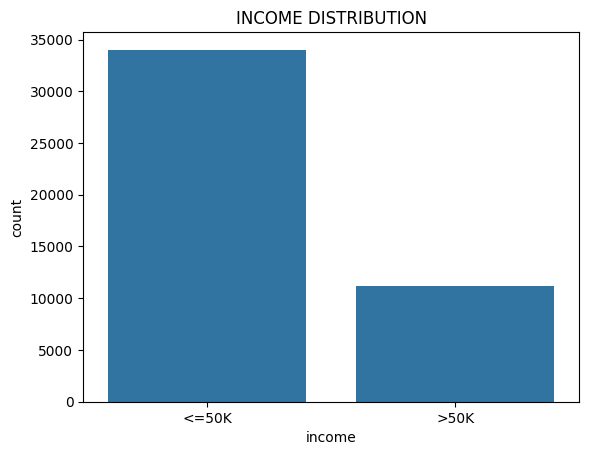

In [23]:
sns.countplot(data=df,x='income')
plt.title('INCOME DISTRIBUTION')
plt.show()

In [24]:
df['income'].value_counts(normalize=True)

income
<=50K    0.752156
>50K     0.247844
Name: proportion, dtype: float64

### histogram

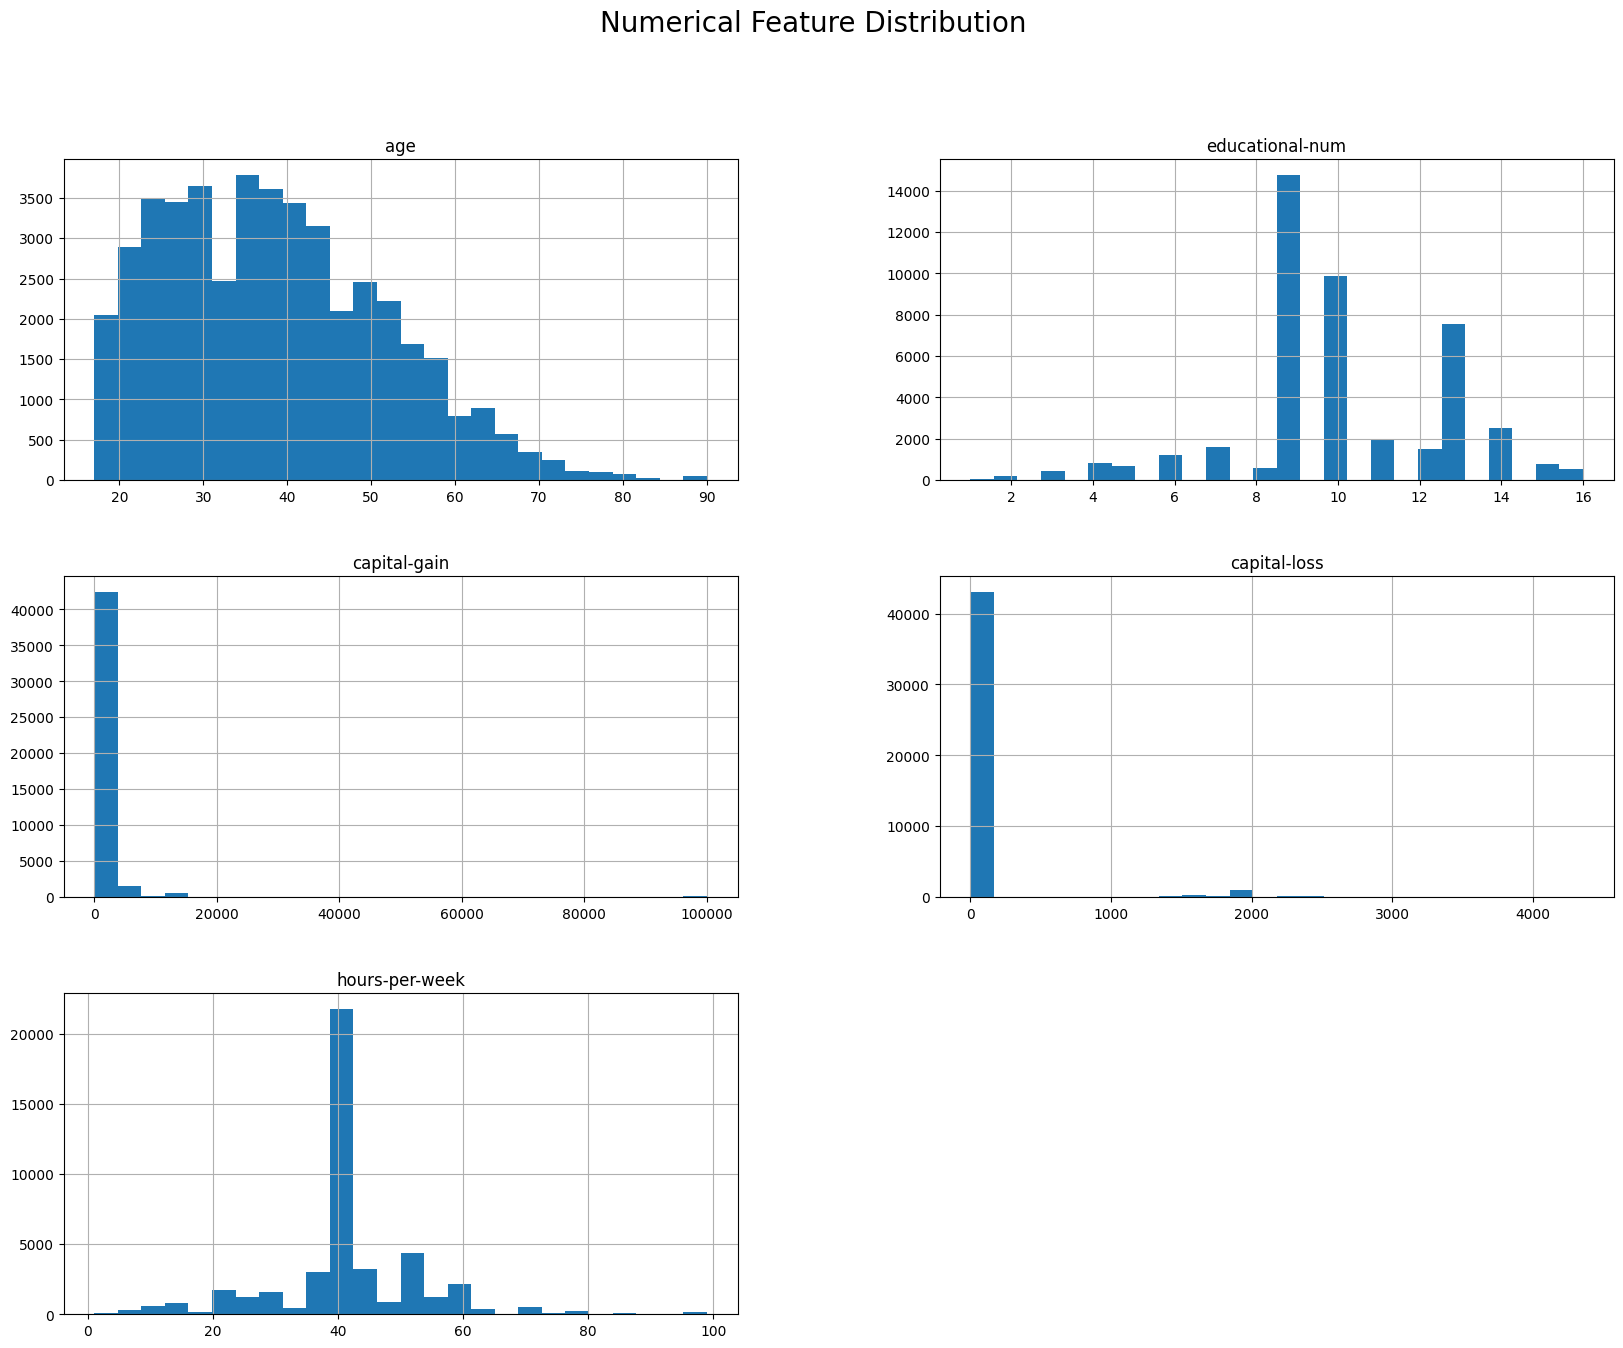

In [25]:
# HISTPLOT
df.hist(figsize=(20, 15), bins=26)
plt.suptitle("Numerical Feature Distribution", fontsize=20)
plt.show()

<Axes: >

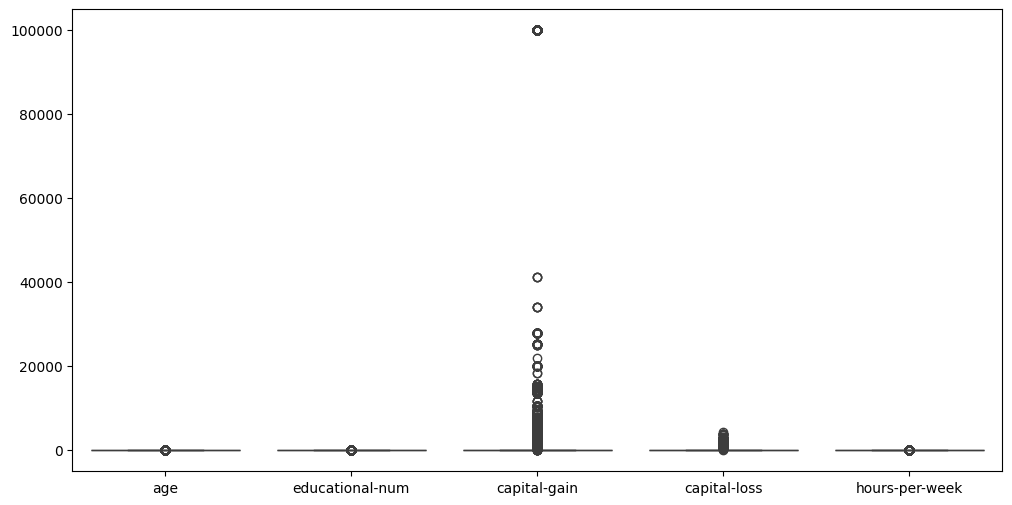

In [26]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)

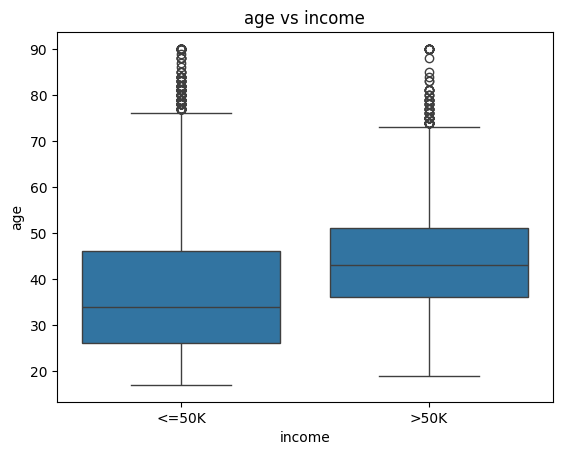

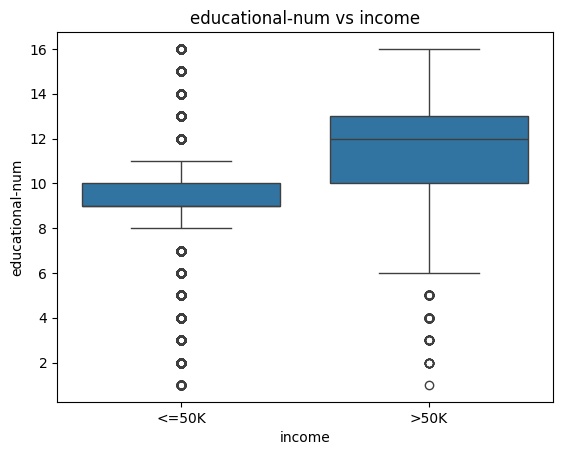

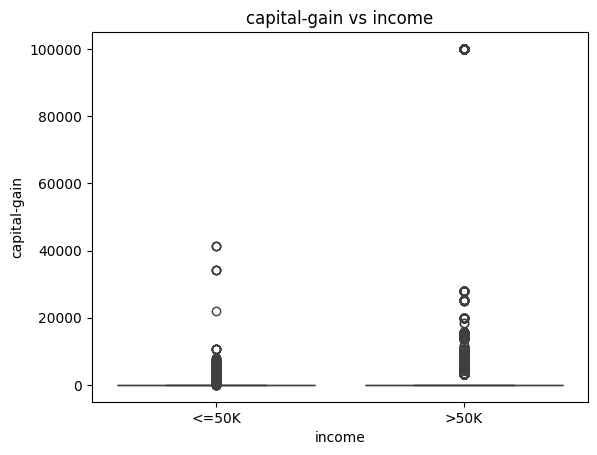

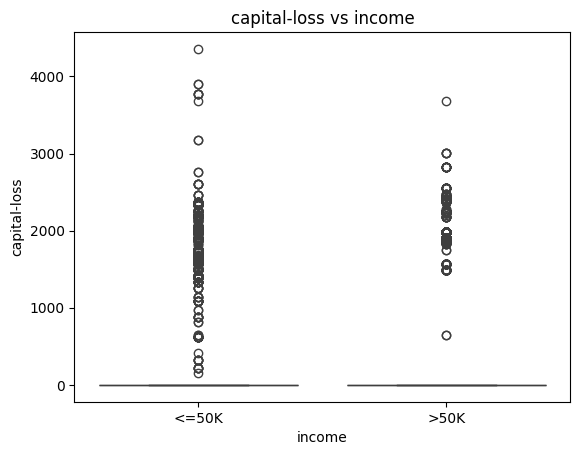

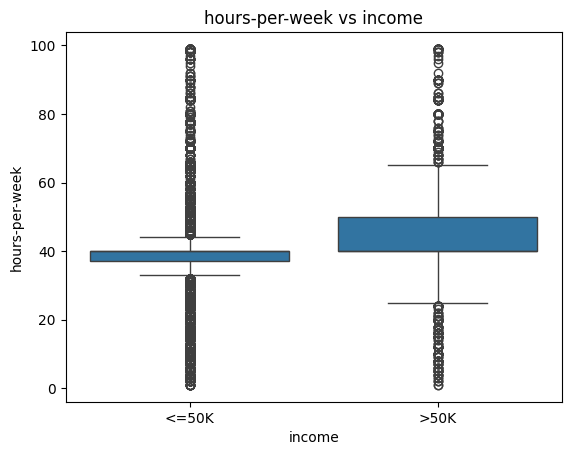

In [27]:
for i in df.select_dtypes(include=['float64', 'int64']).columns:
    sns.boxplot(data=df,x='income',y=i)
    plt.title(f'{i} vs income')
    plt.show()

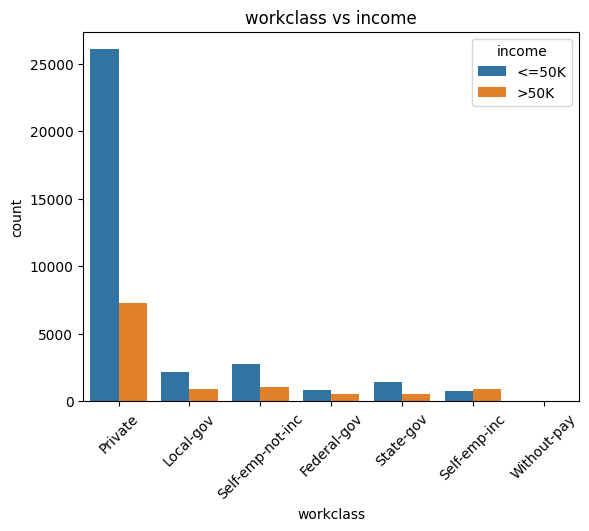

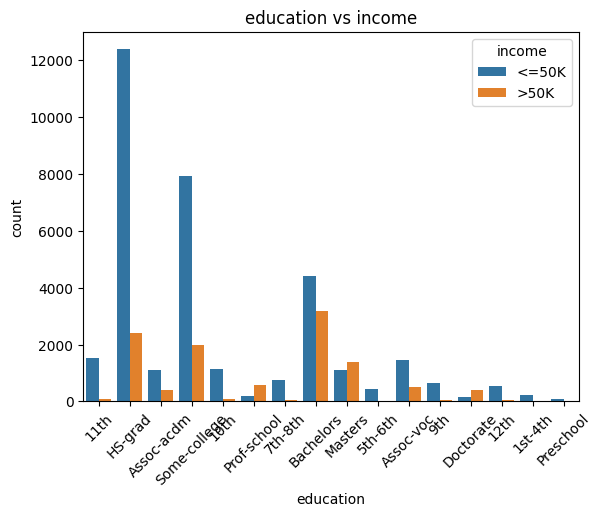

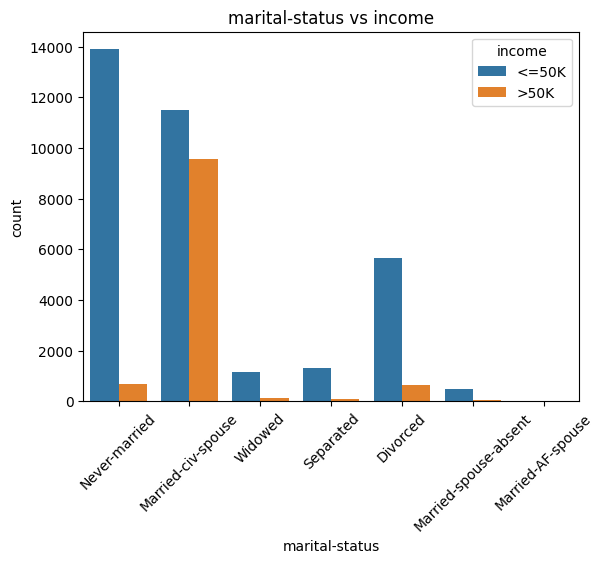

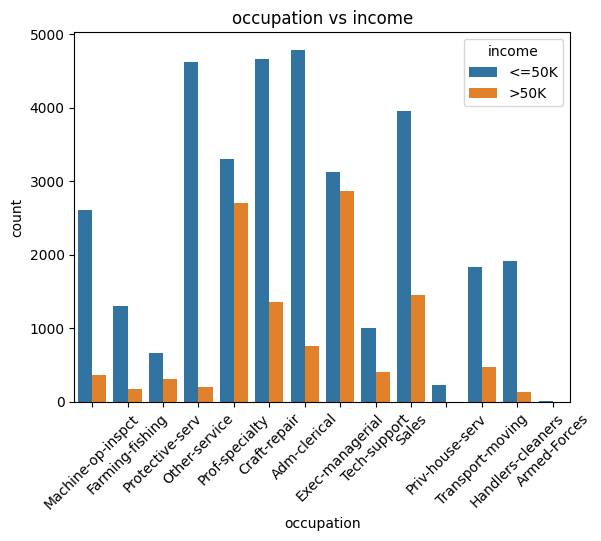

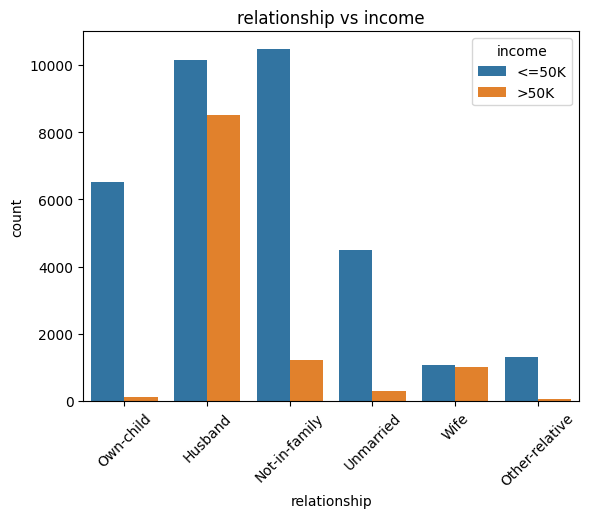

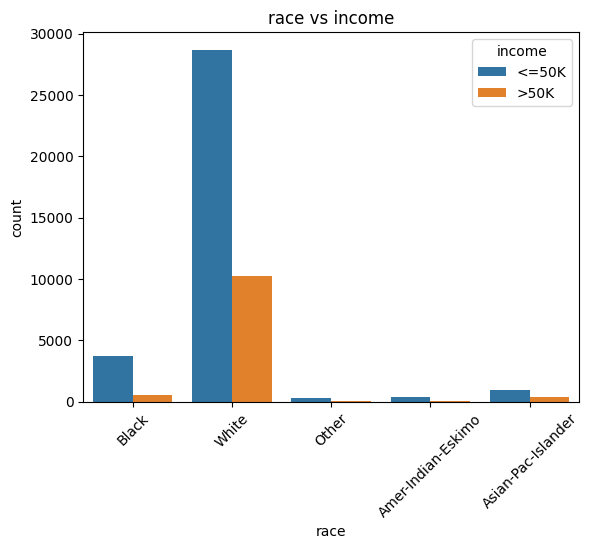

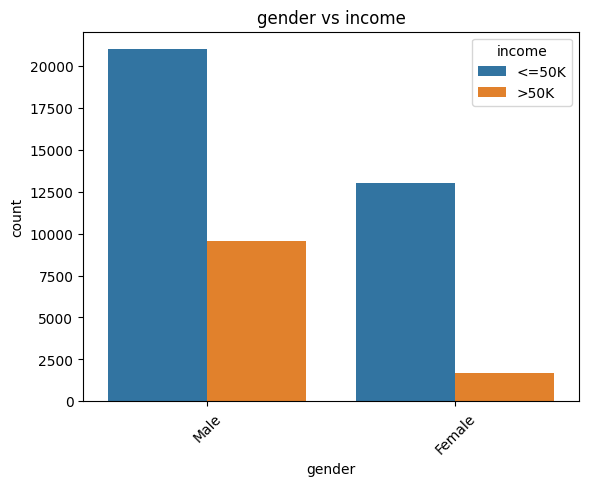

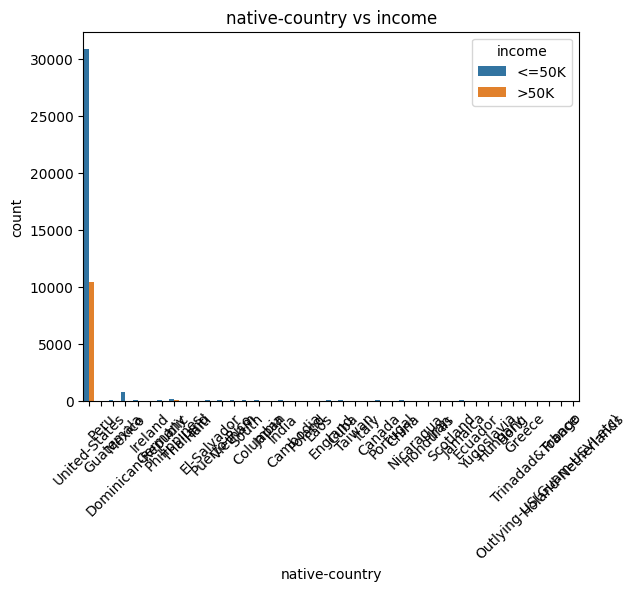

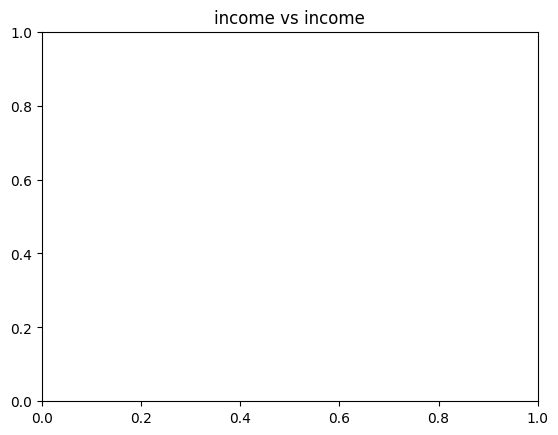

In [28]:
for i in df.select_dtypes(include='object'):
    if i!='income':
        sns.countplot(data=df,x=i,hue='income')
        plt.xticks(rotation=45)
    plt.title(f'{i} vs income')
    plt.show()

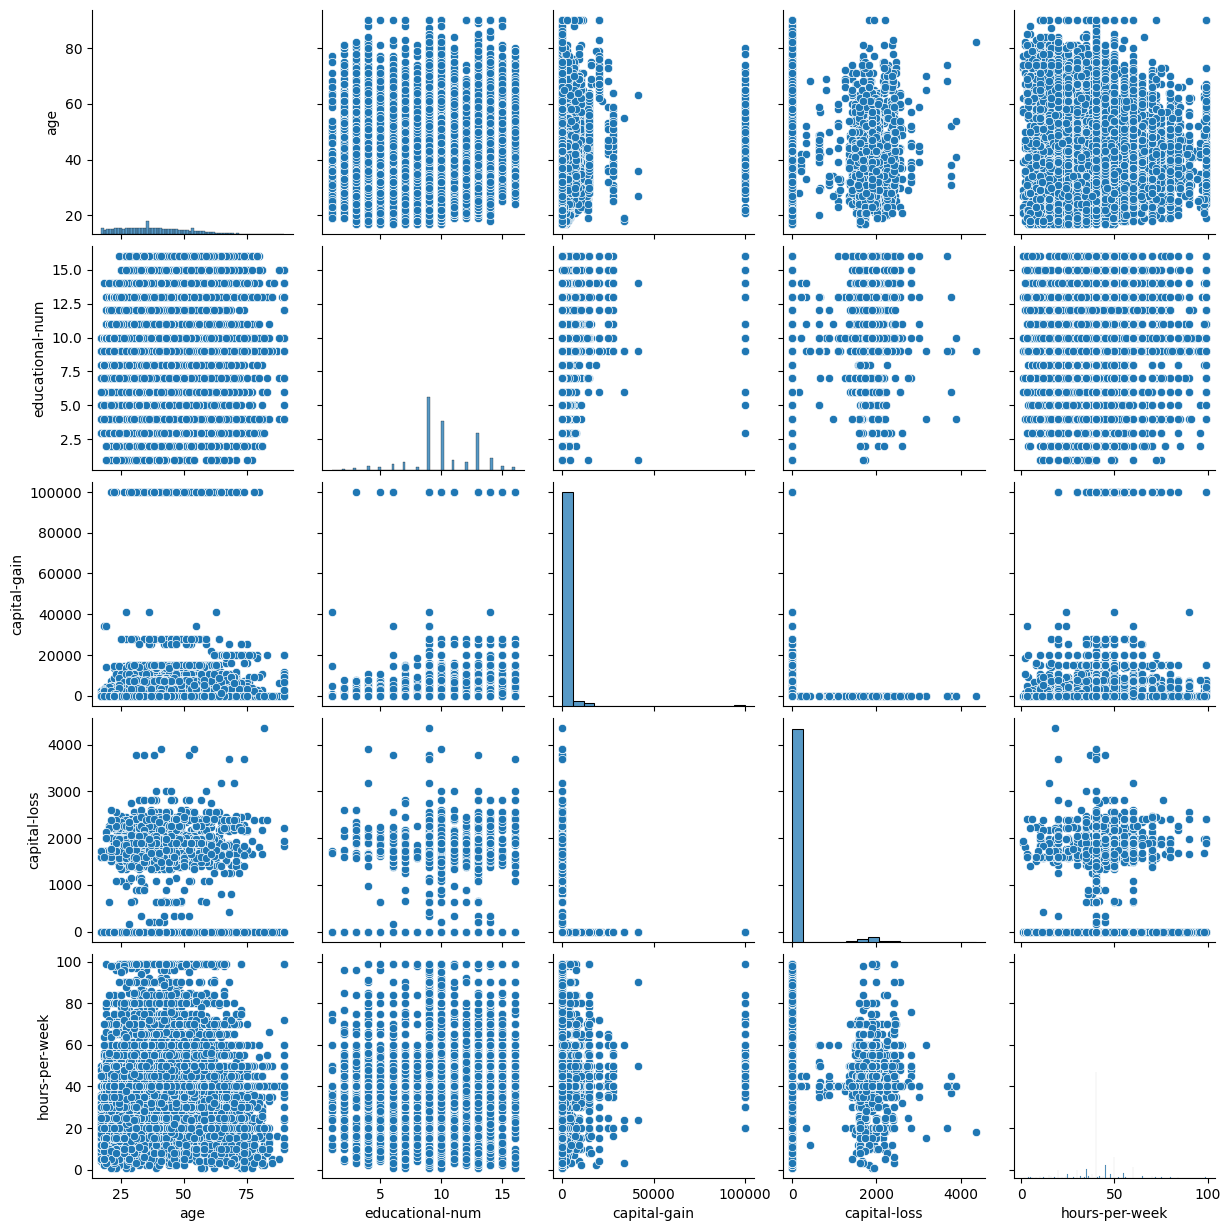

In [29]:
sns.pairplot(data=df)
plt.show()

In [30]:
df.duplicated().sum()

np.int64(5982)

In [31]:
df = df.drop_duplicates()

In [32]:
df.duplicated().sum()

np.int64(0)

Duplicate records were identified and removed to avoid bias in model training.

In [33]:
for col in df.select_dtypes(include=['int64','float64']):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers")

age: 221 outliers
educational-num: 287 outliers
capital-gain: 3752 outliers
capital-loss: 2123 outliers
hours-per-week: 11010 outliers


Although the IQR method identified outliers, these represent genuine economic and demographic variations rather than data errors. Removing them would distort real-world patterns and reduce predictive strength. Therefore, I retained them

Although the IQR method detected statistical outliers, these values represent genuine economic and demographic variations rather than data errors. Removing them would distort real-world patterns and reduce model performance, especially for high-income individuals.

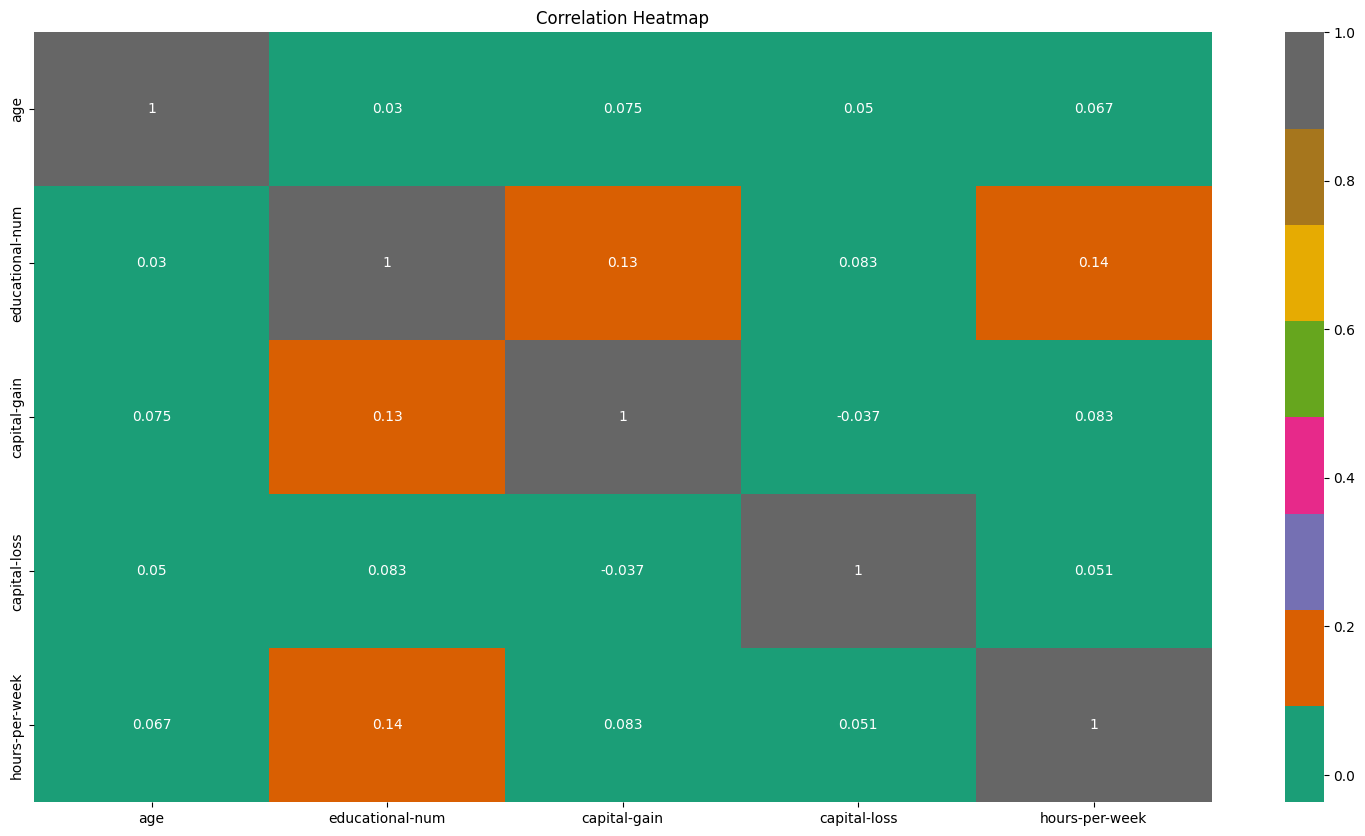

In [34]:
plt.figure(figsize=(19,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Dark2')
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows no strong linear relationships among numerical features, indicating absence of multicollinearity. Educational level shows slight positive association with capital gain and working hours, which aligns with real-world expectations. Since no correlation exceeds critical thresholds, all numerical features were retained.

In [35]:
df.dtypes

age                 int64
workclass          object
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

# Preprocessing

In [36]:
df

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48835,53,Private,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
48836,22,Private,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [37]:
le1= LabelEncoder()
le2= LabelEncoder()
le3= LabelEncoder()
le4= LabelEncoder()
le5= LabelEncoder()
le6= LabelEncoder()
le7= LabelEncoder()
le8= LabelEncoder()
le9= LabelEncoder()

df['gender'] = le1.fit_transform(df['gender'])
df['income'] = le2.fit_transform(df['income'])
df['native-country']=le3.fit_transform(df['native-country'])
df['race']=le4.fit_transform(df['race'])
df['relationship']=le5.fit_transform(df['relationship'])
df['occupation']=le6.fit_transform(df['occupation'])
df['marital-status']=le7.fit_transform(df['marital-status'])
df['education']=le8.fit_transform(df['education'])
df['workclass']=le9.fit_transform(df['workclass'])

In [38]:
df

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,2,1,7,4,6,3,2,1,0,0,40,38,0
1,38,2,11,9,2,4,0,4,1,0,0,50,38,0
2,28,1,7,12,2,10,0,4,1,0,0,40,38,1
3,44,2,15,10,2,6,0,2,1,7688,0,40,38,1
5,34,2,0,6,4,7,1,4,1,0,0,30,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48835,53,2,12,14,2,3,0,4,1,0,0,40,38,1
48836,22,2,15,10,4,10,1,4,1,0,0,40,38,0
48837,27,2,7,12,2,12,5,4,0,0,0,38,38,0
48839,58,2,11,9,6,0,4,4,0,0,0,40,38,0


In [39]:
x=df.drop('income',axis=1)
x

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,2,1,7,4,6,3,2,1,0,0,40,38
1,38,2,11,9,2,4,0,4,1,0,0,50,38
2,28,1,7,12,2,10,0,4,1,0,0,40,38
3,44,2,15,10,2,6,0,2,1,7688,0,40,38
5,34,2,0,6,4,7,1,4,1,0,0,30,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48835,53,2,12,14,2,3,0,4,1,0,0,40,38
48836,22,2,15,10,4,10,1,4,1,0,0,40,38
48837,27,2,7,12,2,12,5,4,0,0,0,38,38
48839,58,2,11,9,6,0,4,4,0,0,0,40,38


In [40]:
y=df[['income']]
y

,income
0,0
1,0
2,1
3,1
5,0
...,...
48835,1
48836,0
48837,0
48839,0


In [41]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [42]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

# Logistic Regression

Test score: 0.8093781855249745
train score: 0.8195081549439348
CR:               precision    recall  f1-score   support

           0       0.83      0.94      0.88      5800
           1       0.72      0.44      0.55      2048

    accuracy                           0.81      7848
   macro avg       0.77      0.69      0.71      7848
weighted avg       0.80      0.81      0.79      7848

Test accuracy: 80.93781855249745
Train accuracy: 81.95081549439348


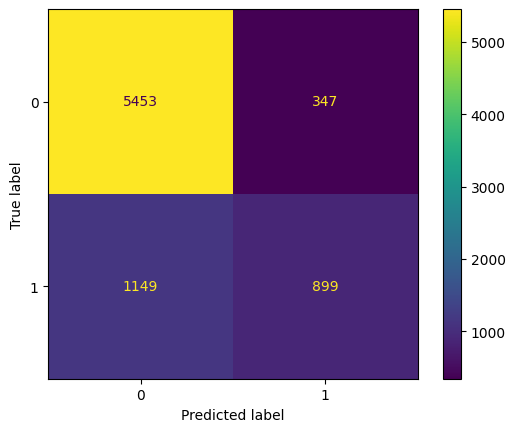

In [43]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_testpred=lr.predict(x_test)
y_trainpred=lr.predict(x_train)
print('Test score:',lr.score(x_test,y_test))
print('train score:',lr.score(x_train,y_train))
ConfusionMatrixDisplay.from_predictions(y_test,y_testpred)
print('CR:',classification_report(y_test,y_testpred))
lrt=accuracy_score(y_test,y_testpred)*100
lrr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',lrt)
print('Train accuracy:',lrr)

The Logistic Regression model achieved 81% test accuracy with minimal overfitting. However, recall for the high-income class is relatively low at 44%, indicating the model struggles to correctly identify higher earners due to class imbalance. This suggests potential improvement using class balancing techniques."

# DecisionTree

Test accuracy: 0.8436544342507645
train accuracy: 0.846967380224261
CR:               precision    recall  f1-score   support

           0       0.86      0.94      0.90      5800
           1       0.78      0.56      0.65      2048

    accuracy                           0.84      7848
   macro avg       0.82      0.75      0.78      7848
weighted avg       0.84      0.84      0.83      7848

Test accuracy: 84.36544342507645
Train accuracy: 84.6967380224261


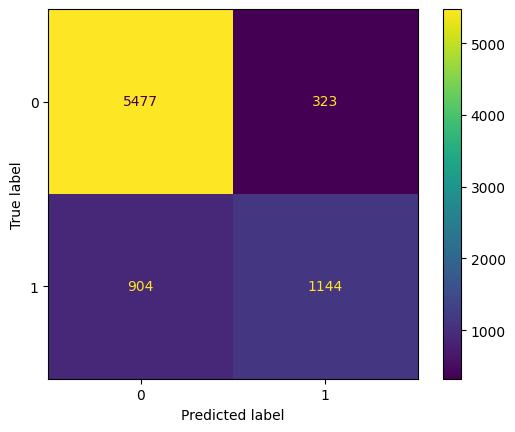

In [44]:
dt=DecisionTreeClassifier(max_depth=6)
dt.fit(x_train,y_train)
y_testpred=dt.predict(x_test)
y_trainpred=dt.predict(x_train)
print('Test accuracy:',dt.score(x_test,y_test))
print('train accuracy:',dt.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
dtt=accuracy_score(y_test,y_testpred)*100
dtr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',dtt)
print('Train accuracy:',dtr)

Decision Tree:

Identifies more high-income individuals (recall 56%)

Better for targeting premium customers

# RandomForest

Test accuracy: 0.8245412844036697
train accuracy: 0.9803453109072375
CR:               precision    recall  f1-score   support

           0       0.86      0.91      0.88      5800
           1       0.69      0.59      0.64      2048

    accuracy                           0.82      7848
   macro avg       0.78      0.75      0.76      7848
weighted avg       0.82      0.82      0.82      7848

Test accuracy: 82.45412844036697
Train accuracy: 98.03453109072376


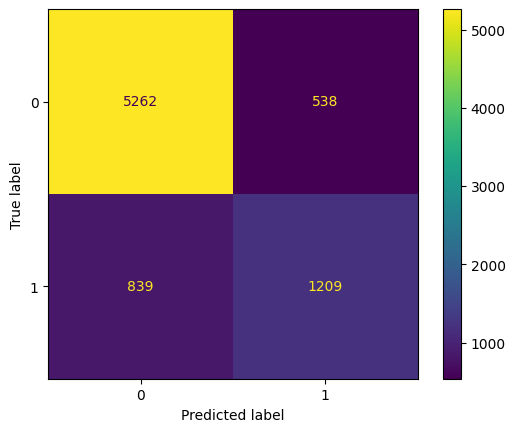

In [45]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
y_testpred=rf.predict(x_test)
y_trainpred=rf.predict(x_train)
print('Test accuracy:',rf.score(x_test,y_test))
print('train accuracy:',rf.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
rft=accuracy_score(y_test,y_testpred)*100
rfr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',rft)
print('Train accuracy:',rfr)

The Random Forest model achieved 82% test accuracy but showed significant overfitting, with 98% training accuracy. Although it improved high-income detection (59% recall), its generalization performance was weaker compared to the tuned Decision Tree. Therefore, it was not selected as the final model.

# KNN(K NEAREST NEIGHBOR CLASSIFICATION)

Test accuracy: 0.8126911314984709
train accuracy: 0.8722604485219164
CR:               precision    recall  f1-score   support

           0       0.86      0.90      0.88      5800
           1       0.66      0.57      0.61      2048

    accuracy                           0.81      7848
   macro avg       0.76      0.74      0.75      7848
weighted avg       0.81      0.81      0.81      7848

Test accuracy: 81.2691131498471
Train accuracy: 87.22604485219165


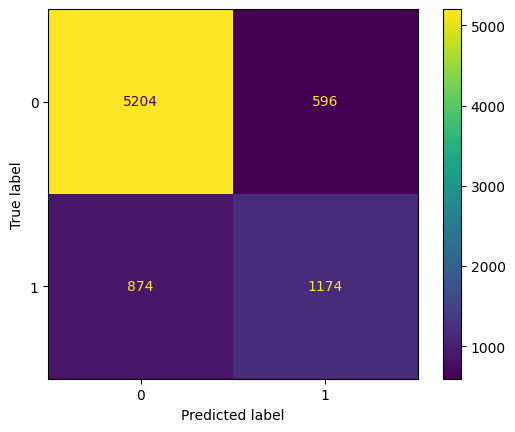

In [46]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_testpred=knn.predict(x_test)
y_trainpred=knn.predict(x_train)
print('Test accuracy:',knn.score(x_test,y_test))
print('train accuracy:',knn.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
knnt=accuracy_score(y_test,y_testpred)*100
knnr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',knnt)
print('Train accuracy:',knnr)

The KNN model with k=5 achieved 81.27% test accuracy and 87.23% training accuracy, showing moderate overfitting but improved generalization compared to k=3. The model performed well in predicting the majority class (≤50K) with 90% recall, while identifying 57% of high-income individuals (>50K). Although tuning reduced variance and stabilized performance, the overall accuracy remained lower than the optimized Decision Tree, making KNN a competitive but not the best-performing model in this study

# SVC

Test score: 0.8379204892966361
train score: 0.8478593272171254
CR:               precision    recall  f1-score   support

           0       0.85      0.94      0.90      5800
           1       0.76      0.55      0.64      2048

    accuracy                           0.84      7848
   macro avg       0.81      0.74      0.77      7848
weighted avg       0.83      0.84      0.83      7848

Test accuracy: 83.79204892966361
Train accuracy: 84.78593272171254


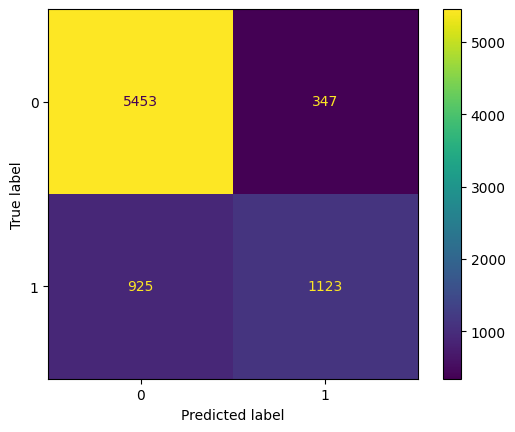

In [47]:
sv=SVC()
sv.fit(x_train,y_train)
y_testpred=sv.predict(x_test)
y_trainpred=sv.predict(x_train)
print('Test score:',sv.score(x_test,y_test))
print('train score:',sv.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
svt=accuracy_score(y_test,y_testpred)*100
svr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',svt)
print('Train accuracy:',svr)

he Support Vector Classifier achieved 83.79% test accuracy with minimal overfitting. It generalizes better than Random Forest and performs more consistently. However, recall for the minority class remains moderate, indicating room for improvement in detecting class 1.

The Support Vector Classifier achieved 83.79% test accuracy with minimal overfitting. It generalizes better than Random Forest and performs more consistently. However, recall for the minority class remains moderate, indicating room for improvement in detecting class 1.

# GaussianNB

Test accuracy: 0.7915392456676861
train accuracy: 0.7968590723751274
CR:               precision    recall  f1-score   support

           0       0.80      0.95      0.87      5800
           1       0.70      0.35      0.46      2048

    accuracy                           0.79      7848
   macro avg       0.75      0.65      0.67      7848
weighted avg       0.78      0.79      0.76      7848

Test accuracy: 79.15392456676861
Train accuracy: 79.68590723751274


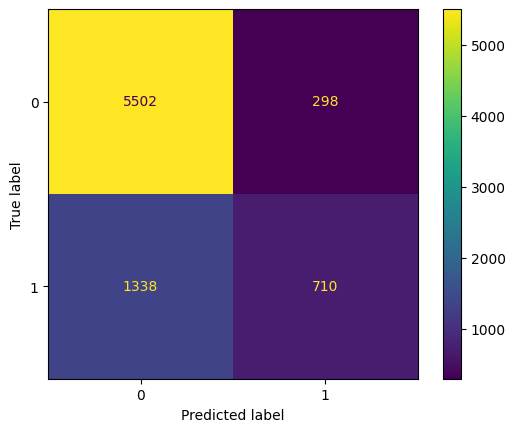

In [48]:
gnb=GaussianNB()
gnb.fit(x_train,y_train)
y_testpred=gnb.predict(x_test)
y_trainpred=gnb.predict(x_train)
print('Test accuracy:',gnb.score(x_test,y_test))
print('train accuracy:',gnb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
gnbt=accuracy_score(y_test,y_testpred)*100
gnbr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',gnbt)
print('Train accuracy:',gnbr)

Gaussian Naive Bayes performs very well for the majority class with high recall (95%), but struggles with the minority class, achieving only 35% recall. This indicates difficulty in detecting Class 1 instances, likely due to class imbalance and the strong independence assumption of the model.

# ADABOOST

Test accuracy: 0.8160040774719673
train accuracy: 0.8238723241590215
CR:               precision    recall  f1-score   support

           0       0.81      0.98      0.89      5800
           1       0.87      0.35      0.50      2048

    accuracy                           0.82      7848
   macro avg       0.84      0.66      0.69      7848
weighted avg       0.82      0.82      0.79      7848

Test accuracy: 81.60040774719674
Train accuracy: 82.38723241590215


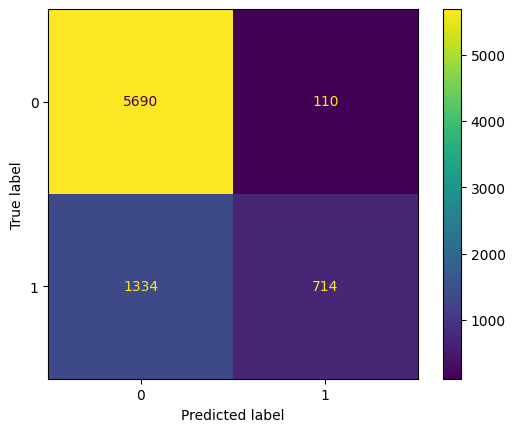

In [49]:
adaboost=AdaBoostClassifier(n_estimators=50,estimator=None,learning_rate=0.2,random_state=5)
adaboost.fit(x_train,y_train)
y_testpred=adaboost.predict(x_test)
y_trainpred=adaboost.predict(x_train)
print('Test accuracy:',adaboost.score(x_test,y_test))
print('train accuracy:',adaboost.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
adt=accuracy_score(y_test,y_testpred)*100
adr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',adt)
print('Train accuracy:',adr)

AdaBoost achieved 81.6% test accuracy with minimal overfitting. While it showed very high precision for the minority class, recall remained low, indicating difficulty in detecting all Class 1 instances. The model generalizes well but favors the majority class due to dataset imbalance.

# GradientBoost

Test accuracy: 0.8474770642201835
train accuracy: 0.8535614169215087
CR:               precision    recall  f1-score   support

           0       0.86      0.95      0.90      5800
           1       0.81      0.54      0.65      2048

    accuracy                           0.85      7848
   macro avg       0.83      0.75      0.78      7848
weighted avg       0.84      0.85      0.84      7848

Test accuracy: 84.74770642201835
Train accuracy: 85.35614169215087


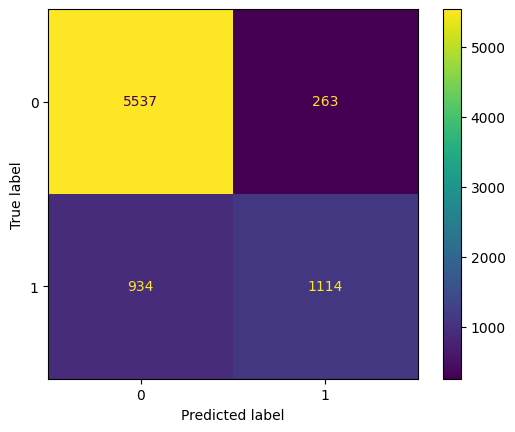

In [50]:
gbc=GradientBoostingClassifier(n_estimators=100,learning_rate=0.05,random_state=200)
gbc.fit(x_train,y_train)
y_testpred=gbc.predict(x_test)
y_trainpred=gbc.predict(x_train)
print('Test accuracy:',gbc.score(x_test,y_test))
print('train accuracy:',gbc.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
gbt=accuracy_score(y_test,y_testpred)*100
gbr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',gbt)
print('Train accuracy:',gbr)

Gradient Boosting achieved the highest test accuracy of 84.75% with minimal overfitting. It maintained strong performance across both classes and demonstrated the best balance between bias and variance, making it the most suitable model for deployment.

Gradient Boosting minimizes errors sequentially using gradient descent optimization, whereas AdaBoost focuses mainly on reweighting misclassified samples. Gradient Boosting generally achieves better performance with controlled learning rates.

# XGBClassifier

Test accuracy: 0.8635321100917431
train accuracy: 0.888315494393476
CR:               precision    recall  f1-score   support

           0       0.89      0.93      0.91      5800
           1       0.77      0.68      0.72      2048

    accuracy                           0.86      7848
   macro avg       0.83      0.80      0.82      7848
weighted avg       0.86      0.86      0.86      7848

Test accuracy: 86.35321100917432
Train accuracy: 88.8315494393476


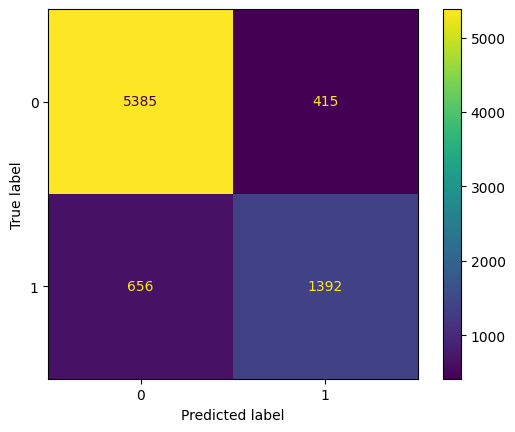

In [51]:
xgb = XGBClassifier()
xgb.fit(x_train,y_train)
y_testpred=xgb.predict(x_test)
y_trainpred=xgb.predict(x_train)
print('Test accuracy:',xgb.score(x_test,y_test))
print('train accuracy:',xgb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
xgt=accuracy_score(y_test,y_testpred)*100
xgr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',xgt)
print('Train accuracy:',xgr)

XGBoost achieved the highest test accuracy of 86.35% with strong minority class recall of 68%. Although there is slight overfitting, it maintains strong generalization and provides the best balance between precision and recall. Therefore, XGBoost is selected as the final deployment model.

In [52]:
tb=pd.DataFrame()
tb['model']=pd.Series(['knn','lr','gnb','rf','adaboost','gbc','dt','xgb','sv'])
tb['test_accuracy']=pd.Series([knnt,lrt,gnbt,rft,adt,gbt,dtt,xgt,svt])
tb['train_accuracy']=pd.Series([knnr,lrr,gnbr,rfr,adr,gbr,dtr,xgr,svr])
tb

,model,test_accuracy,train_accuracy
0,knn,81.269113,87.226045
1,lr,80.937819,81.950815
2,gnb,79.153925,79.685907
3,rf,82.454128,98.034531
4,adaboost,81.600408,82.387232
5,gbc,84.747706,85.356142
6,dt,84.365443,84.696738
7,xgb,86.353211,88.831549
8,sv,83.792049,84.785933


# SMOTE(Synthetic Minority Over-sampling Technique)

In [53]:
from imblearn.over_sampling import SMOTE
#from collections import Counter
# Apply SMOTE
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=60)
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train,y_train)
y_train.value_counts()


income
0         21913
1         21913
Name: count, dtype: int64

In [54]:
#x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.25,random_state=60)

In [55]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

# LOGISTIC REGRESSION

Test score: 0.7602446483180428
train score: 0.7679003331355816
CR:               precision    recall  f1-score   support

           0       0.90      0.77      0.83      7352
           1       0.52      0.74      0.61      2458

    accuracy                           0.76      9810
   macro avg       0.71      0.75      0.72      9810
weighted avg       0.80      0.76      0.77      9810

Test accuracy: 76.02446483180428
Train accuracy: 76.79003331355815


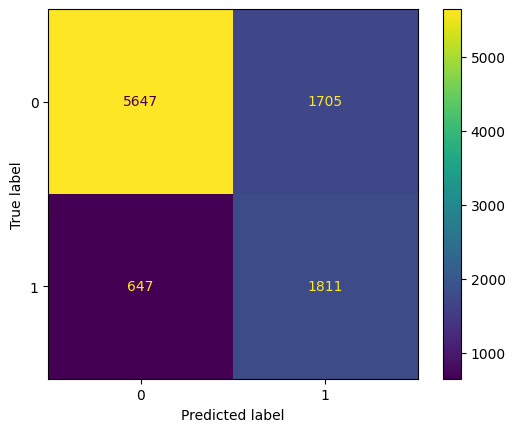

In [56]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_testpred=lr.predict(x_test)
y_trainpred=lr.predict(x_train)
print('Test score:',lr.score(x_test,y_test))
print('train score:',lr.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
lrt=accuracy_score(y_test,y_testpred)*100
lrr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',lrt)
print('Train accuracy:',lrr)

After applying SMOTE, minority class recall improved significantly from around 55% to 71%, indicating better detection of Class 1 instances. Although overall accuracy decreased slightly, the model became more balanced and fair in classification.

# DECISION TREE

Test accuracy: 0.8097859327217125
train accuracy: 0.8263587824579017
CR:               precision    recall  f1-score   support

           0       0.92      0.82      0.87      7352
           1       0.59      0.78      0.67      2458

    accuracy                           0.81      9810
   macro avg       0.75      0.80      0.77      9810
weighted avg       0.84      0.81      0.82      9810

Test accuracy: 80.97859327217125
Train accuracy: 82.63587824579017


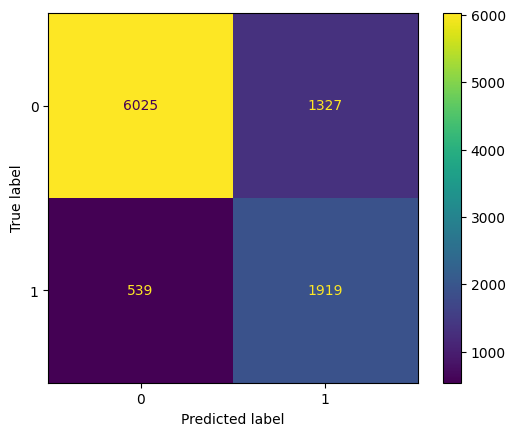

In [57]:
dt=DecisionTreeClassifier(criterion='entropy',max_depth=6)
dt.fit(x_train,y_train)
y_testpred=dt.predict(x_test)
y_trainpred=dt.predict(x_train)
print('Test accuracy:',dt.score(x_test,y_test))
print('train accuracy:',dt.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
dtt=accuracy_score(y_test,y_testpred)*100
dtr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',dtt)
print('Train accuracy:',dtr)

The tuned Decision Tree model achieved 80.97% test accuracy with only a 1.6% train–test gap, indicating good generalization. After applying SMOTE, minority class recall improved to 78%, demonstrating effective handling of class imbalance. Overall, the model shows balanced and stable performance.

# RANDOM FOREST

Test accuracy: 0.8226299694189603
train accuracy: 0.982544608223429
CR:               precision    recall  f1-score   support

           0       0.89      0.87      0.88      7352
           1       0.64      0.68      0.66      2458

    accuracy                           0.82      9810
   macro avg       0.76      0.77      0.77      9810
weighted avg       0.83      0.82      0.82      9810

Test accuracy: 82.26299694189603
Train accuracy: 98.2544608223429


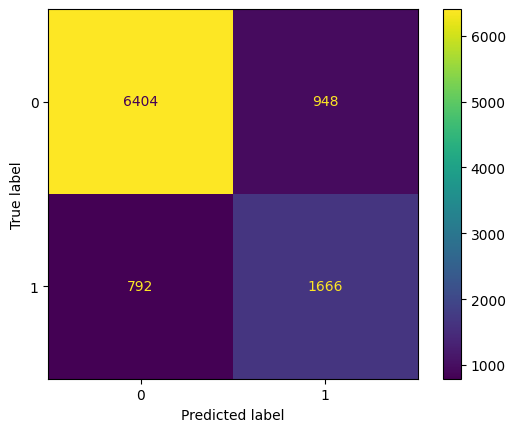

In [58]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
y_testpred=rf.predict(x_test)
y_trainpred=rf.predict(x_train)
print('Test accuracy:',rf.score(x_test,y_test))
print('train accuracy:',rf.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
rft=accuracy_score(y_test,y_testpred)*100
rfr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',rft)
print('Train accuracy:',rfr)

The Random Forest model with 100 estimators achieved the highest test accuracy (82.4%), but showed significant overfitting with 98% training accuracy. While overall performance improved, minority class recall (69%) remained lower than the tuned Decision Tree model, indicating the need for further regularization.

# knn

Test accuracy: 0.7906218144750254
train accuracy: 0.8940126865331082
CR:               precision    recall  f1-score   support

           0       0.90      0.81      0.85      7352
           1       0.56      0.72      0.63      2458

    accuracy                           0.79      9810
   macro avg       0.73      0.77      0.74      9810
weighted avg       0.81      0.79      0.80      9810

Test accuracy: 79.06218144750254
Train accuracy: 89.40126865331082


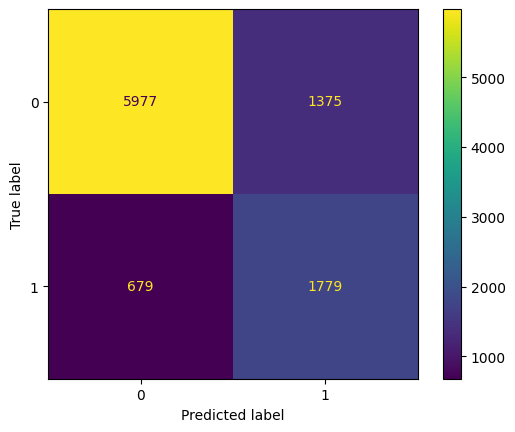

In [59]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_testpred=knn.predict(x_test)
y_trainpred=knn.predict(x_train)
print('Test accuracy:',knn.score(x_test,y_test))
print('train accuracy:',knn.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
knnt=accuracy_score(y_test,y_testpred)*100
knnr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',knnt)
print('Train accuracy:',knnr)

# svc

Test score: 0.8013251783893985
train score: 0.8456167571761055
CR:               precision    recall  f1-score   support

           0       0.93      0.80      0.86      7352
           1       0.57      0.82      0.67      2458

    accuracy                           0.80      9810
   macro avg       0.75      0.81      0.77      9810
weighted avg       0.84      0.80      0.81      9810

Test accuracy: 80.13251783893985
Train accuracy: 84.56167571761056


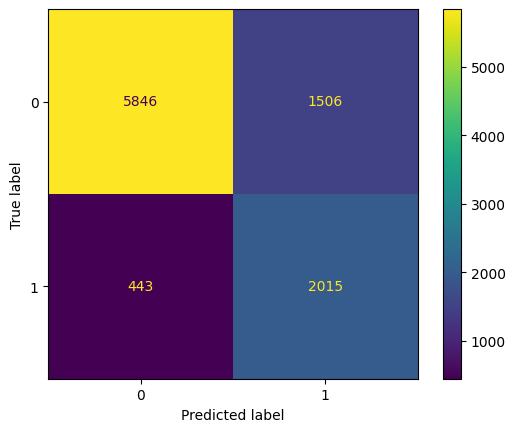

In [60]:
sv=SVC()
sv.fit(x_train,y_train)
y_testpred=sv.predict(x_test)
y_trainpred=sv.predict(x_train)
print('Test score:',sv.score(x_test,y_test))
print('train score:',sv.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
svt=accuracy_score(y_test,y_testpred)*100
svr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',svt)
print('Train accuracy:',svr)

# gaussian nb

Test accuracy: 0.8114169215086646
train accuracy: 0.7067266006480172
CR:               precision    recall  f1-score   support

           0       0.84      0.92      0.88      7352
           1       0.68      0.47      0.56      2458

    accuracy                           0.81      9810
   macro avg       0.76      0.70      0.72      9810
weighted avg       0.80      0.81      0.80      9810

Test accuracy: 81.14169215086646
Train accuracy: 70.67266006480172


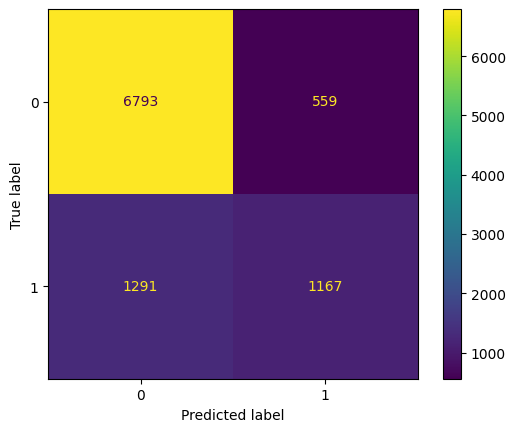

In [61]:
gb=GaussianNB()
gb.fit(x_train,y_train)
y_testpred=gb.predict(x_test)
y_trainpred=gb.predict(x_train)
print('Test accuracy:',gb.score(x_test,y_test))
print('train accuracy:',gb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
gbt=accuracy_score(y_test,y_testpred)*100
gbr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',gbt)
print('Train accuracy:',gbr)

# adaboost

Test accuracy: 0.7277268093781856
train accuracy: 0.7625382193218637
CR:               precision    recall  f1-score   support

           0       0.90      0.71      0.80      7352
           1       0.47      0.77      0.59      2458

    accuracy                           0.73      9810
   macro avg       0.69      0.74      0.69      9810
weighted avg       0.80      0.73      0.74      9810

Test accuracy: 72.77268093781856
Train accuracy: 76.25382193218637


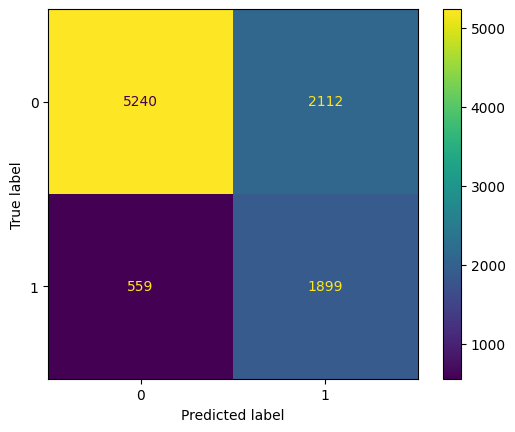

In [62]:
adaboost=AdaBoostClassifier(n_estimators=10,estimator=None,learning_rate=0.2,random_state=5)
adaboost.fit(x_train,y_train)
y_testpred=adaboost.predict(x_test)
y_trainpred=adaboost.predict(x_train)
print('Test accuracy:',adaboost.score(x_test,y_test))
print('train accuracy:',adaboost.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
adt=accuracy_score(y_test,y_testpred)*100
adr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',adt)
print('Train accuracy:',adr)

# GRADIENT BOOST

Test accuracy: 0.8190621814475025
train accuracy: 0.8425592114270068
CR:               precision    recall  f1-score   support

           0       0.93      0.82      0.87      7352
           1       0.60      0.82      0.69      2458

    accuracy                           0.82      9810
   macro avg       0.77      0.82      0.78      9810
weighted avg       0.85      0.82      0.83      9810

Test accuracy: 81.90621814475026
Train accuracy: 84.25592114270069


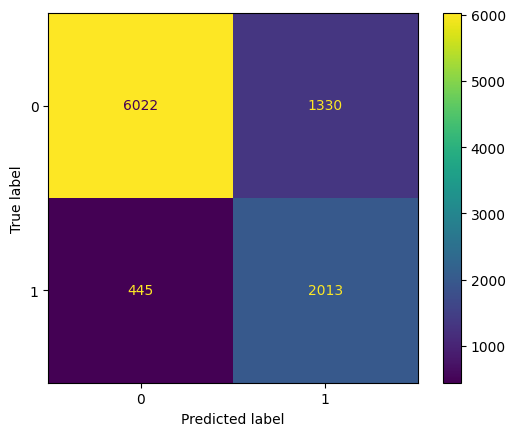

In [63]:
gbc=GradientBoostingClassifier(n_estimators=100,learning_rate=0.05,random_state=200)
gbc.fit(x_train,y_train)
y_testpred=gbc.predict(x_test)
y_trainpred=gbc.predict(x_train)
print('Test accuracy:',gbc.score(x_test,y_test))
print('train accuracy:',gbc.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
gbt=accuracy_score(y_test,y_testpred)*100
gbr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',gbt)
print('Train accuracy:',gbr)

# XG-BOOST

Test accuracy: 0.8418960244648318
train accuracy: 0.8977319399443253
CR:               precision    recall  f1-score   support

           0       0.93      0.86      0.89      7352
           1       0.65      0.80      0.72      2458

    accuracy                           0.84      9810
   macro avg       0.79      0.83      0.80      9810
weighted avg       0.86      0.84      0.85      9810

Test accuracy: 84.18960244648318
Train accuracy: 89.77319399443253


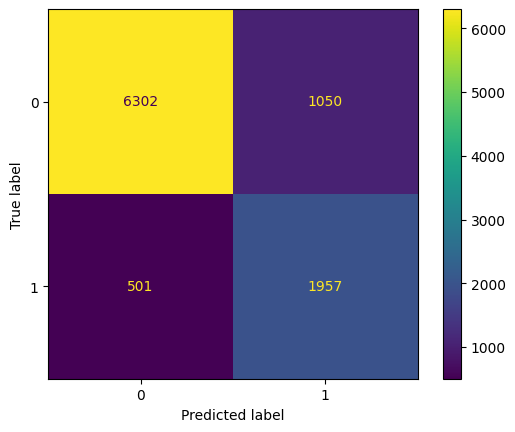

In [64]:
xgb= XGBClassifier()
xgb.fit(x_train, y_train)
y_testpred=xgb.predict(x_test)
y_trainpred=xgb.predict(x_train)
print('Test accuracy:',xgb.score(x_test,y_test))
print('train accuracy:',xgb.score(x_train,y_train))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_testpred))
print('CR:',classification_report(y_test,y_testpred))
xgt=accuracy_score(y_test,y_testpred)*100
xgr=accuracy_score(y_train,y_trainpred)*100
print('Test accuracy:',xgt)
print('Train accuracy:',xgr)

# PERFORMANCE AFTER SMOTE

In [90]:
tb=pd.DataFrame()
tb['model']=pd.Series(['knn','lr','gnb','rf','adaboost','gbc','dt','xgb','sv'])
tb['test_accuracy']=pd.Series([knnt,lrt,gnbt,rft,adt,gbt,dtt,xgt,svt])
tb['train_accuracy']=pd.Series([knnr,lrr,gnbr,rfr,adr,gbr,dtr,xgr,svr])
print('Performance after smot')
tb

Performance after smot


,model,test_accuracy,train_accuracy
0,knn,79.062181,89.401269
1,lr,76.024465,76.790033
2,gnb,79.153925,79.685907
3,rf,82.262997,98.254461
4,adaboost,72.772681,76.253822
5,gbc,81.906218,84.255921
6,dt,80.978593,82.635878
7,xgb,84.189602,89.773194
8,sv,80.132518,84.561676


# HYPERPARAMETER TUNNING

In [66]:
# RANDOM FOREST
rf_params={'n_estimators':[10,50,100],'max_depth':[2,4,6,None]}
rf_grid=GridSearchCV(RandomForestClassifier(random_state=42),rf_params,cv=5)
rf_grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 

In [67]:
from sklearn.svm import LinearSVC
svm_params = {'C':[0.1,1,10]}
svm_grid = GridSearchCV(LinearSVC(), svm_params, cv=5)
svm_grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also disp

In [68]:
# DECISION TREE

dt_params={'max_depth':[2,4,6,None],'criterion':['gini','entropy']}
dt_grid=GridSearchCV(DecisionTreeClassifier(random_state=42),dt_params,cv=3)
dt_grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [69]:
# LOGITIC REGRESSION

lr_params={'C':[0.1,1,10]}
lr_grid=GridSearchCV(LogisticRegression(),lr_params,cv=5)
lr_grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are 

In [70]:
knn_param = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']}
knn_grid = GridSearchCV(KNeighborsClassifier(),knn_param,cv=3,scoring='accuracy',n_jobs=-1)
knn_grid.fit(x_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [71]:
# gb
gb_param = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42),gb_param , cv=5, scoring='accuracy', n_jobs=-1)
gb_grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [72]:
xgb_params = {
    'n_estimators': [200, 300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'gamma': [0, 0.1]
}
xgb_grid = GridSearchCV(XGBClassifier(),xgb_params,cv=5,scoring='accuracy', n_jobs=-1,verbose=1)
xgb_grid.fit(x_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1], 'gamma': [0, 0.1], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [75]:
models = {'Random Forest': rf_grid,'SVM': svm_grid,'Logistic Regression': lr_grid,'Decision Tree': dt_grid,'KNN':knn_grid,'GB':gb_grid,'xgb':xgb_grid}
for name, grid in models.items():
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}:")
    print(f"  Best Params: {grid.best_params_}")
    print(f"  Accuracy: {acc:.4f}\n")

Random Forest:
  Best Params: {'max_depth': None, 'n_estimators': 100}
  Accuracy: 0.8226

SVM:
  Best Params: {'C': 0.1}
  Accuracy: 0.7578

Logistic Regression:
  Best Params: {'C': 1}
  Accuracy: 0.7602

Decision Tree:
  Best Params: {'criterion': 'entropy', 'max_depth': None}
  Accuracy: 0.7839

KNN:
  Best Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
  Accuracy: 0.7920

GB:
  Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'min_samples_split': 10, 'n_estimators': 300}
  Accuracy: 0.8403

xgb:
  Best Params: {'colsample_bytree': 1, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
  Accuracy: 0.8442



In [76]:
# Access the best model
best_xgb_model = xgb_grid.best_estimator_
y_pred = best_xgb_model.predict(x_test)

In [77]:
print(best_xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


In [78]:
joblib.dump(xgb,"adult_income.pkl")

['adult_income.pkl']

In [79]:
joblib.dump(sc,'scaler.pkl')

['scaler.pkl']

In [80]:
joblib.dump(le1,'le1.pkl')

['le1.pkl']

In [81]:
joblib.dump(le2,'le2.pkl')

['le2.pkl']

In [82]:
joblib.dump(le3,'le3.pkl')

['le3.pkl']

In [83]:
joblib.dump(le4,'le4.pkl')

['le4.pkl']

In [84]:
joblib.dump(le5,'le5.pkl')

['le5.pkl']

In [85]:
joblib.dump(le6,'le6.pkl')

['le6.pkl']

In [86]:
joblib.dump(le7,'le7.pkl')

['le7.pkl']

In [87]:
joblib.dump(le8,'le8.pkl')

['le8.pkl']

In [88]:
joblib.dump(le9,'le9.pkl')

['le9.pkl']

In [89]:

x.columns

Index(['age', 'workclass', 'education', 'educational-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object')